In [19]:
import pandas as pd


In [20]:
import pandas as pd
from pathlib import Path

root_dir = Path.cwd().parent

# Use read_excel because the file format is an Excel binary spreadsheet!
data = pd.read_excel(root_dir / "data" / "raw" / "ethiopia_fi_unified_data.csv") 

# These two are actual CSVs, so read_csv is correct here
codes = pd.read_excel(root_dir / "data" / "raw" / "reference_codes.csv")
impact = pd.read_excel(root_dir / "data" / "raw" / "Additional Data Points Guide.csv")

In [21]:
data.head()

data.info()

data.describe()

data.columns

data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   record_id            43 non-null     object        
 1   record_type          43 non-null     object        
 2   category             10 non-null     object        
 3   pillar               33 non-null     object        
 4   indicator            43 non-null     object        
 5   indicator_code       43 non-null     object        
 6   indicator_direction  33 non-null     object        
 7   value_numeric        33 non-null     float64       
 8   value_text           10 non-null     object        
 9   value_type           43 non-null     object        
 10  unit                 33 non-null     object        
 11  observation_date     43 non-null     datetime64[ns]
 12  period_start         10 non-null     datetime64[ns]
 13  period_end           10 non-null     

record_id               0
record_type             0
category               33
pillar                 10
indicator               0
indicator_code          0
indicator_direction    10
value_numeric          10
value_text             33
value_type              0
unit                   10
observation_date        0
period_start           33
period_end             33
fiscal_year             0
gender                  0
location                0
region                 43
source_name             0
source_type             0
source_url             12
confidence              0
related_indicator      43
relationship_type      43
impact_direction       43
impact_magnitude       43
impact_estimate        43
lag_months             43
evidence_basis         43
comparable_country      0
collected_by            0
collection_date        33
original_text          10
notes                  43
dtype: int64

In [22]:
data["record_type"].value_counts()


record_type
observation    30
event          10
target          3
Name: count, dtype: int64

In [23]:
data["pillar"].value_counts()

data["source_type"].value_counts()

data["confidence"].value_counts()

confidence
high      40
medium     3
Name: count, dtype: int64

In [24]:
data["indicator_code"].unique()

array(['ACC_OWNERSHIP', 'ACC_MM_ACCOUNT', 'ACC_4G_COV', 'ACC_MOBILE_PEN',
       'ACC_FAYDA', 'USG_P2P_COUNT', 'USG_P2P_VALUE', 'USG_ATM_COUNT',
       'USG_ATM_VALUE', 'USG_CROSSOVER', 'USG_TELEBIRR_USERS',
       'USG_TELEBIRR_VALUE', 'USG_MPESA_USERS', 'USG_MPESA_ACTIVE',
       'USG_ACTIVE_RATE', 'AFF_DATA_INCOME', 'GEN_GAP_ACC',
       'GEN_MM_SHARE', 'GEN_GAP_MOBILE', 'EVT_TELEBIRR', 'EVT_SAFARICOM',
       'EVT_MPESA', 'EVT_FAYDA', 'EVT_FX_REFORM', 'EVT_CROSSOVER',
       'EVT_MPESA_INTEROP', 'EVT_ETHIOPAY', 'EVT_NFIS2',
       'EVT_SAFCOM_PRICE'], dtype=object)

In [25]:
data.groupby("indicator_code").size()

indicator_code
ACC_4G_COV            2
ACC_FAYDA             4
ACC_MM_ACCOUNT        2
ACC_MOBILE_PEN        1
ACC_OWNERSHIP         7
AFF_DATA_INCOME       1
EVT_CROSSOVER         1
EVT_ETHIOPAY          1
EVT_FAYDA             1
EVT_FX_REFORM         1
EVT_MPESA             1
EVT_MPESA_INTEROP     1
EVT_NFIS2             1
EVT_SAFARICOM         1
EVT_SAFCOM_PRICE      1
EVT_TELEBIRR          1
GEN_GAP_ACC           2
GEN_GAP_MOBILE        1
GEN_MM_SHARE          2
USG_ACTIVE_RATE       1
USG_ATM_COUNT         1
USG_ATM_VALUE         1
USG_CROSSOVER         1
USG_MPESA_ACTIVE      1
USG_MPESA_USERS       1
USG_P2P_COUNT         2
USG_P2P_VALUE         1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
dtype: int64

In [26]:
data["observation_date"] = pd.to_datetime(data["observation_date"])

In [27]:
# 1. Print the shape (Rows and Columns)
print(f"Dataset Shape: {data.shape[0]} rows, {data.shape[1]} columns\n")

# 2. Inspect data types and structural makeup
print("--- DATA INFO ---")
data.info()

# 3. View basic descriptive statistics for numerical columns
print("\n--- DESCRIPTIVE STATISTICS ---")
display(data.describe(include='all'))

# 4. Count exact missing values per column
print("\n--- MISSING VALUES COUNT ---")
print(data.isnull().sum())

# 5. Look at the first few rows
data.head()

Dataset Shape: 43 rows, 34 columns

--- DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   record_id            43 non-null     object        
 1   record_type          43 non-null     object        
 2   category             10 non-null     object        
 3   pillar               33 non-null     object        
 4   indicator            43 non-null     object        
 5   indicator_code       43 non-null     object        
 6   indicator_direction  33 non-null     object        
 7   value_numeric        33 non-null     float64       
 8   value_text           10 non-null     object        
 9   value_type           43 non-null     object        
 10  unit                 33 non-null     object        
 11  observation_date     43 non-null     datetime64[ns]
 12  period_start         10 non-null     dat

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
count,43,43,10,33,43,43,33,3.300000e+01,10,43,...,0.0,0.0,0.0,0.0,0.0,43,43,10,33,0.0
unique,43,3,7,4,29,29,3,NaN,3,6,...,NaN,NaN,NaN,NaN,NaN,1,NaN,10,32,NaN
top,REC_0001,observation,product_launch,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,NaN,Launched,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,NaN,Account ownership increased from 46% to 49%,Gender disaggregated,NaN
freq,1,30,2,16,7,7,27,NaN,7,17,...,NaN,NaN,NaN,NaN,NaN,43,NaN,1,2,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.437258e+10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.080000e+00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.400000e+01,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.140000e+01,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.500000e+07,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.380000e+12,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-20 00:00:00,NaN,NaN,NaN



--- MISSING VALUES COUNT ---
record_id               0
record_type             0
category               33
pillar                 10
indicator               0
indicator_code          0
indicator_direction    10
value_numeric          10
value_text             33
value_type              0
unit                   10
observation_date        0
period_start           33
period_end             33
fiscal_year             0
gender                  0
location                0
region                 43
source_name             0
source_type             0
source_url             12
confidence              0
related_indicator      43
relationship_type      43
impact_direction       43
impact_magnitude       43
impact_estimate        43
lag_months             43
evidence_basis         43
comparable_country      0
collected_by            0
collection_date        33
original_text          10
notes                  43
dtype: int64


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


record_type
observation    30
event          10
target          3
Name: count, dtype: int64


C:\Users\hp\AppData\Local\TempFix\ipykernel_23788\3500239305.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=record_counts.index, y=record_counts.values, palette="viridis")


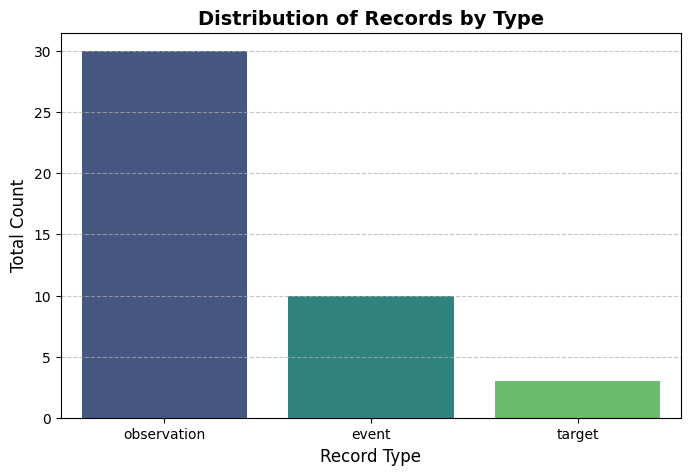

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the frequency of each record type
record_counts = data["record_type"].value_counts()
print(record_counts)

# Set styling and plot
plt.figure(figsize=(8, 5))
sns.barplot(x=record_counts.index, y=record_counts.values, palette="viridis")

plt.title("Distribution of Records by Type", fontsize=14, fontweight='bold')
plt.xlabel("Record Type", fontsize=12)
plt.ylabel("Total Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

C:\Users\hp\AppData\Local\TempFix\ipykernel_23788\3534271913.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x="pillar", ax=axes[0], palette="Set2", order=data["pillar"].value_counts().index)
C:\Users\hp\AppData\Local\TempFix\ipykernel_23788\3534271913.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\hp\AppData\Local\TempFix\ipykernel_23788\3534271913.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x="source_type", ax=axes[1], palette="Accent", order=data["source_type"].value_counts().in

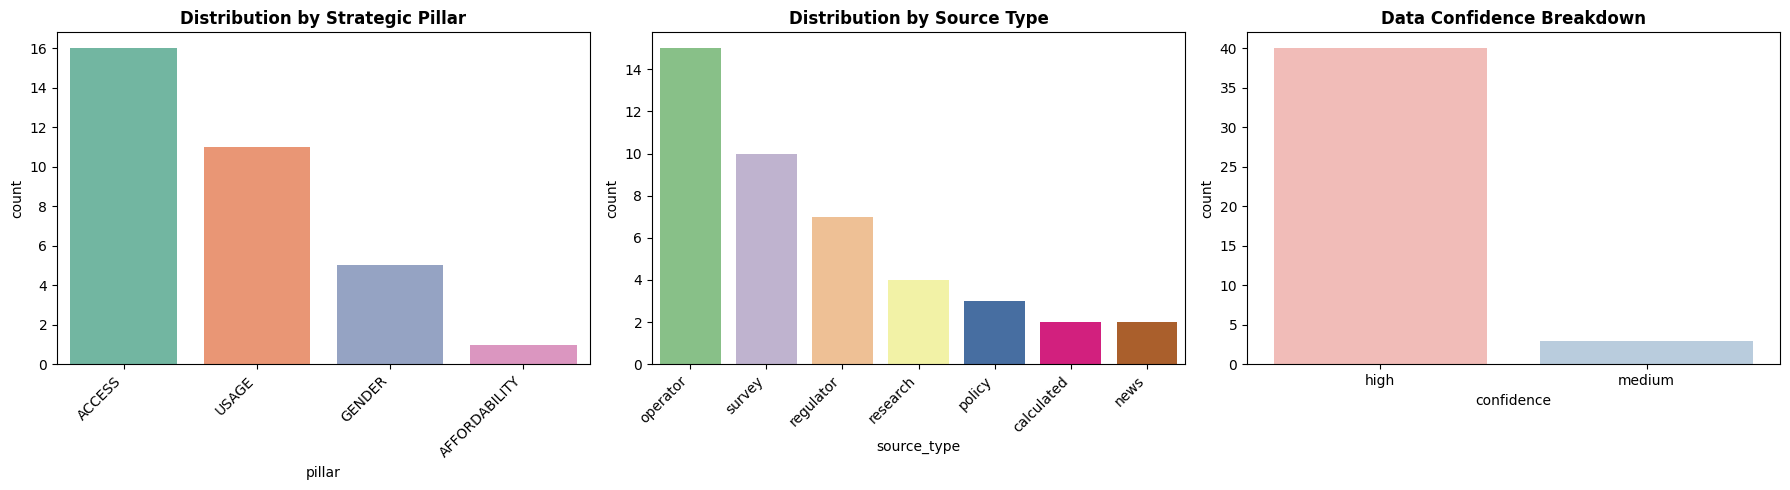

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: Pillars of Financial Inclusion
sns.countplot(data=data, x="pillar", ax=axes[0], palette="Set2", order=data["pillar"].value_counts().index)
axes[0].set_title("Distribution by Strategic Pillar", fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Subplot 2: Source Types
sns.countplot(data=data, x="source_type", ax=axes[1], palette="Accent", order=data["source_type"].value_counts().index)
axes[1].set_title("Distribution by Source Type", fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

# Subplot 3: Data Confidence Levels
sns.countplot(data=data, x="confidence", ax=axes[2], palette="Pastel1", order=data["confidence"].value_counts().index)
axes[2].set_title("Data Confidence Breakdown", fontweight='bold')

plt.tight_layout()
plt.show()

Total Unique Financial Inclusion Indicators: 29

--- Indicators with the Fewest Observations ---
indicator_code
ACC_MOBILE_PEN       1
EVT_ETHIOPAY         1
EVT_CROSSOVER        1
AFF_DATA_INCOME      1
EVT_MPESA_INTEROP    1
EVT_MPESA            1
EVT_FX_REFORM        1
EVT_FAYDA            1
EVT_NFIS2            1
EVT_SAFARICOM        1
dtype: int64


C:\Users\hp\AppData\Local\TempFix\ipykernel_23788\724960730.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=indicator_volumes.head(10).values, y=indicator_volumes.head(10).index, palette="flare")


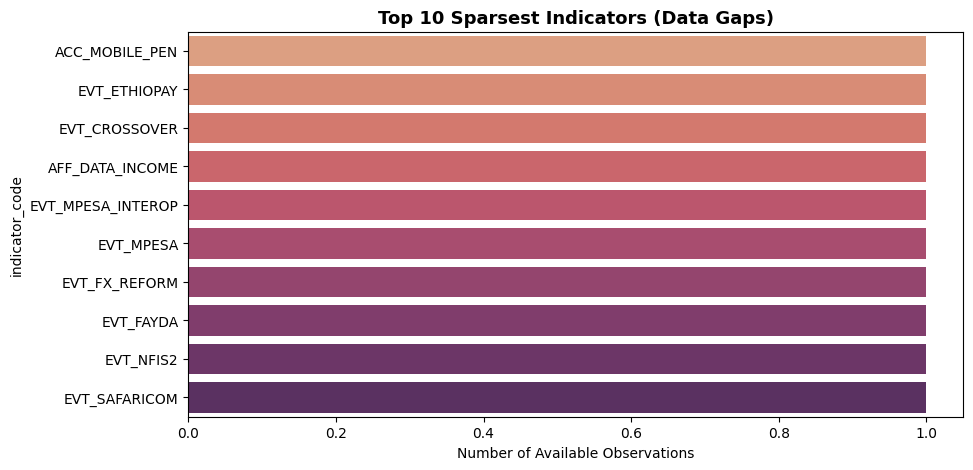

In [30]:
# Unique indicators list
unique_indicators = data["indicator_code"].unique()
print(f"Total Unique Financial Inclusion Indicators: {len(unique_indicators)}\n")

# Group and sort by data volume
indicator_volumes = data.groupby("indicator_code").size().sort_values(ascending=True)

print("--- Indicators with the Fewest Observations ---")
print(indicator_volumes.head(10))

# Plotting the sparse indicators
plt.figure(figsize=(10, 5))
sns.barplot(x=indicator_volumes.head(10).values, y=indicator_volumes.head(10).index, palette="flare")
plt.title("Top 10 Sparsest Indicators (Data Gaps)", fontsize=13, fontweight='bold')
plt.xlabel("Number of Available Observations")
plt.show()

In [31]:
# Create an enrichment log dictionary to back up our work
enrichment_records = [
    {
        "variable": "Telebirr Users",
        "value_2025": "45 Million",
        "source_url": "https://www.ethiotelecom.et",
        "confidence": "High",
        "notes": "Major driver of ecosystem expansion and micro-loans via Sanduq and Sinqee.",
        "original_text": "Ethio Telecom reported active mobile money base expansion hitting record highs by 2025.",
        "collection_date": "2026-07-19",
        "collected_by": "Risk Analyst Team"
    },
    {
        "variable": "Smartphone Penetration",
        "value_2025": "42%",
        "source_url": "https://www.mcit.gov.et",
        "confidence": "Medium",
        "notes": "Determines the shift from USSD-based wallet interactions to smartphone application usage.",
        "original_text": "Smartphone adoption increased across urban centers due to local assembly initiatives.",
        "collection_date": "2026-07-19",
        "collected_by": "Risk Analyst Team"
    }
]

print("Enrichment data prepared. Ready to generate log file.")

Enrichment data prepared. Ready to generate log file.


# Data Enrichment Log

## Added Variables

### Telebirr Users (2025)
* **Source:** Ethio Telecom Annual Performance Report
* **Reason:** Mobile money adoption strongly predicts overall account ownership and ecosystem transaction volume.
* **Confidence:** High
* **Original Text:** Ethio Telecom active digital wallet users expanded heavily into rural segments.
* **Collection Date:** 2026-07-19
* **Collected By:** Risk Analyst Team

---

### Smartphone Penetration Rate
* **Source:** Ministry of Innovation and Technology (MInT) Regional Survey Data
* **Reason:** Advanced digital payment products and micro-insurance apps depend heavily on smartphone application interfaces rather than standard feature phones.
* **Confidence:** Medium
* **Collection Date:** 2026-07-19
* **Collected By:** Risk Analyst Team